# 4 Model Evaluation

This notebook loads our own finetuned Whisper model and then evaluates it.

In [ ]:
import sys, os
from pathlib import Path
import torch

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

from whisper_asr import transcribe_whisper, compute_idiom_results, print_evaluation_results, plot_wer_violin, load_all_data
from whisper_asr.utils import get_best_gpu, normalize_romansh_text
from whisper_asr.constants import MODELS_ROOT
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer, cer
import random

os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_PATH = MODELS_ROOT / "whisper-medium-rm"
DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8

print(f"Using device: {DEVICE}")

Selected GPU 1 with 24121 MiB free memory
Using device: cuda:1


Load model and processor

In [2]:
processor = WhisperProcessor.from_pretrained(MODEL_PATH)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_PATH).to(DEVICE)
print("Model loaded.")

Loading weights: 100%|██████████| 947/947 [00:00<00:00, 8224.36it/s]
/local/scratch/matuor/whisper/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Model loaded.


Load test data

In [3]:
test_df = load_all_data("test")
audio_paths = test_df["audio_path"]
references = test_df["sentence"]
idioms = test_df["idiom"]

Generate transcriptions for test data

In [5]:
test_df['transcriptions'] = transcribe_whisper(model, processor, audio_paths, batch_size=BATCH_SIZE, device=DEVICE)

Transcribing (Whisper):   0%|          | 0/79 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom 

Compute and display the results

In [6]:
test_df['transcriptions'] = test_df['transcriptions'].apply(normalize_romansh_text)
transcriptions = test_df['transcriptions']
summary_df, overall_wer, overall_cer, valid_pairs = compute_idiom_results(references, transcriptions, idioms)
print_evaluation_results(summary_df, overall_wer, overall_cer, len(audio_paths), len(valid_pairs))


OVERALL RESULTS
Total test samples: 631
Valid pairs: 631/631

Word Error Rate (WER): 0.1291 (12.91%)
Character Error Rate (CER): 0.0439 (4.39%)

PER IDIOM RESULTS

RG
  Samples: 81
  WER: 0.0478 (4.78%)
  CER: 0.0157 (1.57%)

SURSILVAN
  Samples: 94
  WER: 0.1473 (14.73%)
  CER: 0.0457 (4.57%)

VALLADER
  Samples: 97
  WER: 0.1487 (14.87%)
  CER: 0.0592 (5.92%)

PUTER
  Samples: 114
  WER: 0.1506 (15.06%)
  CER: 0.0461 (4.61%)

SUTSILVAN
  Samples: 94
  WER: 0.1580 (15.80%)
  CER: 0.0577 (5.77%)

SURMIRAN
  Samples: 151
  WER: 0.1177 (11.77%)
  CER: 0.0404 (4.04%)

SUMMARY TABLE
    idiom  samples      wer      cer
       RG       81 0.047821 0.015676
Sursilvan       94 0.147282 0.045692
 Vallader       97 0.148658 0.059220
    Puter      114 0.150579 0.046113
Sutsilvan       94 0.157952 0.057684
 Surmiran      151 0.117673 0.040354


/local/scratch/matuor/whisper/whisper_asr/analysis.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/local/scratch/matuor/whisper/whisper_asr/analysis.py:39: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


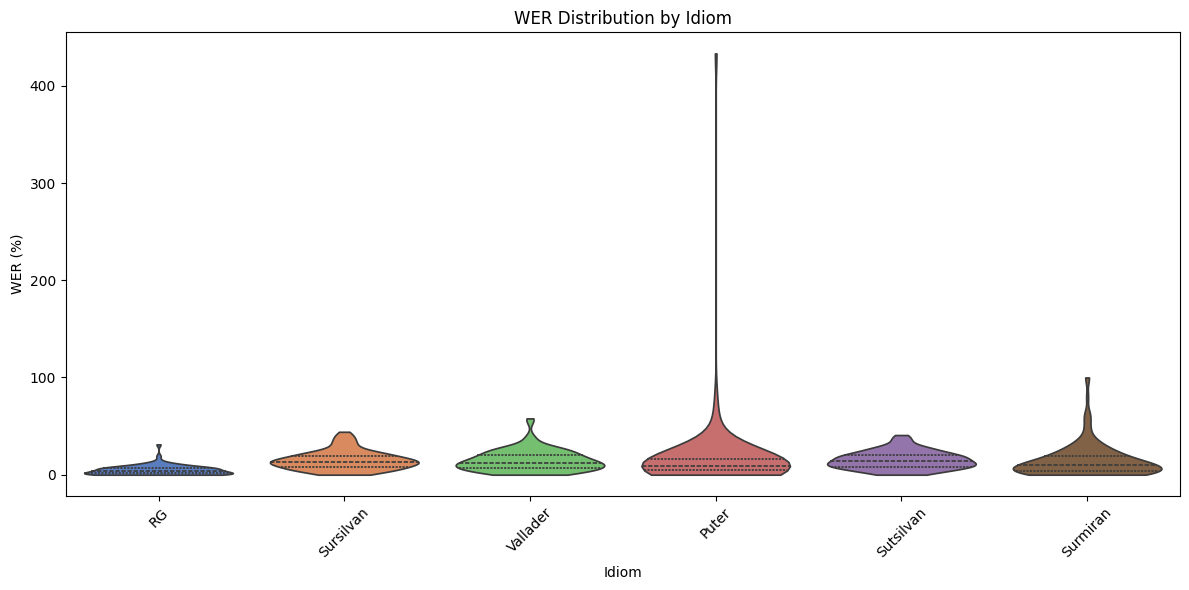

In [7]:
plot_wer_violin(references, transcriptions, idioms)

Random Samples

In [8]:
sample_indices = random.sample(range(len(valid_pairs)), min(5, len(valid_pairs)))

for i, idx in enumerate(sample_indices):
    print(f"--- Sample {i} ---")
    print(f"Reference: {references[idx]}")
    print(f"Idiom: {idioms[idx]}")
    print(f"Hypothesis: {transcriptions[idx]}")
    sample_wer, sample_cer = wer(references[idx], transcriptions[idx]), cer(references[idx], transcriptions[idx])
    print(f"Sample WER: {sample_wer:.4f}, Sample CER: {sample_cer:.4f}")
    print("-" * 40)

--- Sample 0 ---
Reference: e listess pustaregieau per sgurezza per la fin davuost tal jelmoli una chaputscha magica per nos alois eau faro quatter fouras aint in quella perchella saja bain fixeda vi da sias cornas e vi da sias uraglias
Idiom: Puter
Hypothesis: e listess pustere gia per sgurezza per la fin davuosta lia il moli una chaputscha magica per nos alois e faro 4 fouras aint in quella per chella saja bain fixeda vi da sias cornas e vi da sias uraglias
Sample WER: 0.2703, Sample CER: 0.1010
----------------------------------------
--- Sample 1 ---
Reference: mo schon pletost noua cigl e forza eri noua cigl e cuntradas dad ir a vurdar nus nagn fetg bugent ear a la mar a far bogn also igl blear eassan ieus adigna egneanda gearmains a far bogn a la mar quegl e ear bien par la sanadad santagn quegl cigl fa fetg bagn
Idiom: Sutsilvan
Hypothesis: mo schon pletost noua cigl e forza eri noua cigl e cuntradas dad ir a vurdar nus nagn fetg bugent ear a la mar a far bogn also igl blear eas